In [4]:
# =====================================================
# LOGISTIC REGRESSION - BINARY CLASSIFICATION PROJECT
# Dataset: Social Network Ads / Purchased Prediction
# Target:
# 0 = Not Purchased
# 1 = Purchased
# =====================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [5]:
df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Duplicates: 0


In [6]:
# Male = 1
# Female = 0
# =========================
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [7]:
# User ID has no predictive meaning
# =========================
df.drop("User ID", axis=1, inplace=True)

In [8]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression()

model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [14]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.81


Confusion Matrix:
[[59  5]
 [14 22]]


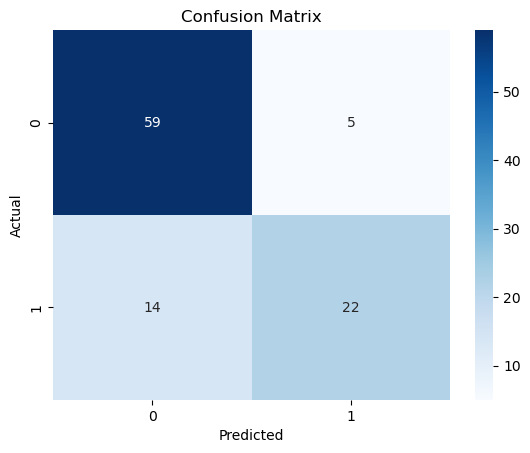

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        64
           1       0.81      0.61      0.70        36

    accuracy                           0.81       100
   macro avg       0.81      0.77      0.78       100
weighted avg       0.81      0.81      0.80       100



In [17]:
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)


ROC AUC Score: 0.9105902777777778


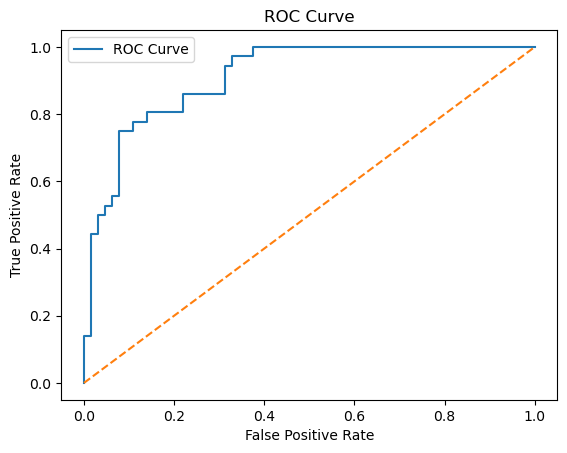

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [20]:
gender = input("Enter Gender (Male/Female): ").strip().title()
age = int(input("Enter Age: "))
salary = int(input("Enter Estimated Salary: "))

# encode gender
if gender == "Male":
    gender = 1
else:
    gender = 0

sample = pd.DataFrame([[gender, age, salary]],
                      columns=["Gender", "Age", "EstimatedSalary"])

sample_scaled = scaler.transform(sample)

result = model.predict(sample_scaled)

if result[0] == 1:
    print("Prediction: User will Purchase")
else:
    print("Prediction: User will NOT Purchase")

Enter Gender (Male/Female):  1
Enter Age:  55
Enter Estimated Salary:  100000


Prediction: User will Purchase
